In [2]:
import numpy as np
from sim_library.simulation import simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, RR3short_gate, exchange10_gate
from sim_library.sequences2 import RR3short_gate as RR3short_gate2
from sim_library.sequences2 import exchange10_gate as exchange10_gate2
from sim_library.data_io import load_p_dists
from sim_library.plotting import plot_coolingcycles_23, plot_coolingcycles_22, plot_coolingcycles_21
from sim_library.constants import k_eff, dR, m, omega_eg, kb
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
N = 6000
Temp = 15e-6

cycles = 96

rabi_freq = 2*pi*1e6
rabi_time = 2*pi/rabi_freq

time_steps = 1

RR3 = exchange10_gate2(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -32
p_max = 32
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
initial_state[32] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

# beam_profile = np.full(N, 1)
# beam_profile = np.random.uniform(0.9, 1.1, N)
beam_profile = np.random.normal(loc=1.0, scale=0.0167, size=N)

moms_list, fracs_list, _ = simulate_alg_cooling_custom(basis=basis, sequence=RR3, time_steps=time_steps, n_atoms=N, temp=Temp, initial_state=initial_state, beam_profile=beam_profile, cycles=cycles, rabi_freq=rabi_freq, pumping_route='f3',
                                                        save_dir='data/algorithmic cooling',
                                                        )

In [29]:
path = Path("data/algorithmic cooling/2026-03-20_algcooling_f3_8cycles_15muK_6000atoms_1e+06Hz_1.h5")
loaded_dict = load_p_dists(file_path=path)
moms_list = loaded_dict["p_list"]
fracs_list = loaded_dict["weights_list"]
basis = loaded_dict["basis"]
Temp = loaded_dict["init_temp"]

In [4]:
moms_list = [mom / (hbar * k_eff) for mom in moms_list]

'plots/histograms/RR2/2026-03-20_RR2_adjustedMDFE_0.05beam_f3_96cycles_15muK_6000atoms_1e6Hz.png' already exists. Save aborted.


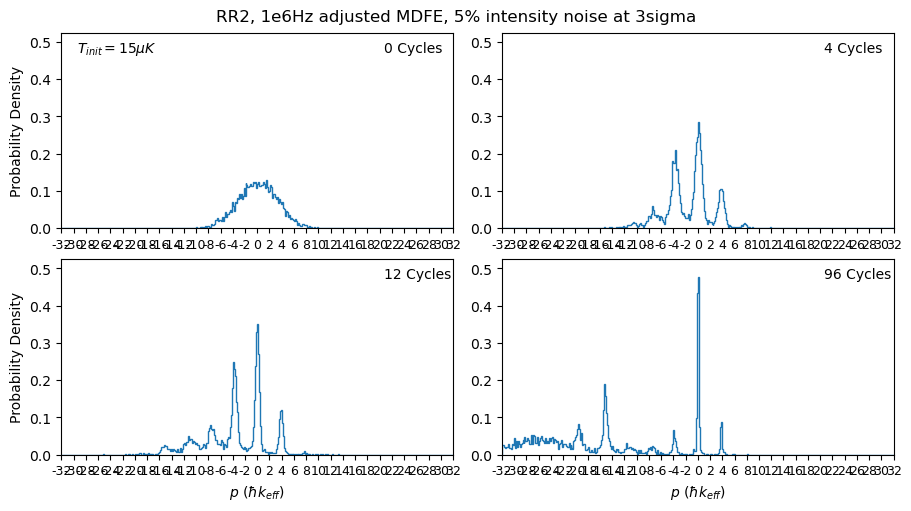

In [5]:


cycles_list = np.array([0,4,12,96])
index_list = np.array([0,8,24,192])
bins_list = np.full(4, 400)
bins_list[0] = 400

plot_coolingcycles_22(moms_list=moms_list, fracs_list=fracs_list, basis=basis, cycles_list=cycles_list, index_list=index_list, bins_list=bins_list, title='RR2, 1e6Hz adjusted MDFE, 5% intensity noise at 3sigma', temp=Temp, show=False,
                    #   ylims=1,
                       save_dir="plots/histograms/RR2/2026-03-20_RR2_adjustedMDFE_0.05beam_f3_96cycles_15muK_6000atoms_1e6Hz.png"
                       )

In [93]:
for mom in fracs_list:
    print(len(mom))

165000
165000
5000
165000
5000
165000
5000
165000
5000
165000
5000
165000
5000
165000
5000
165000
5000


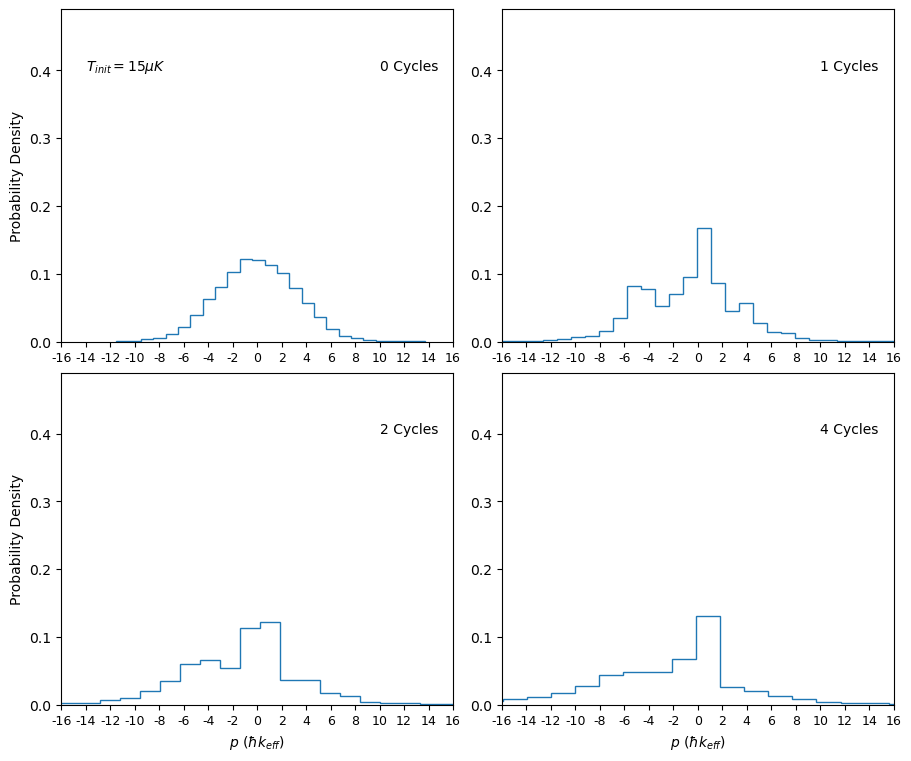

In [14]:
fig1, axes = plt.subplots(2,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 50

index_list = [0,1,3,7]


axes[0].hist(x= moms_list[0], bins = 25, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,4):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[2].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[3].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()


ValueError: weights should have the same shape as x

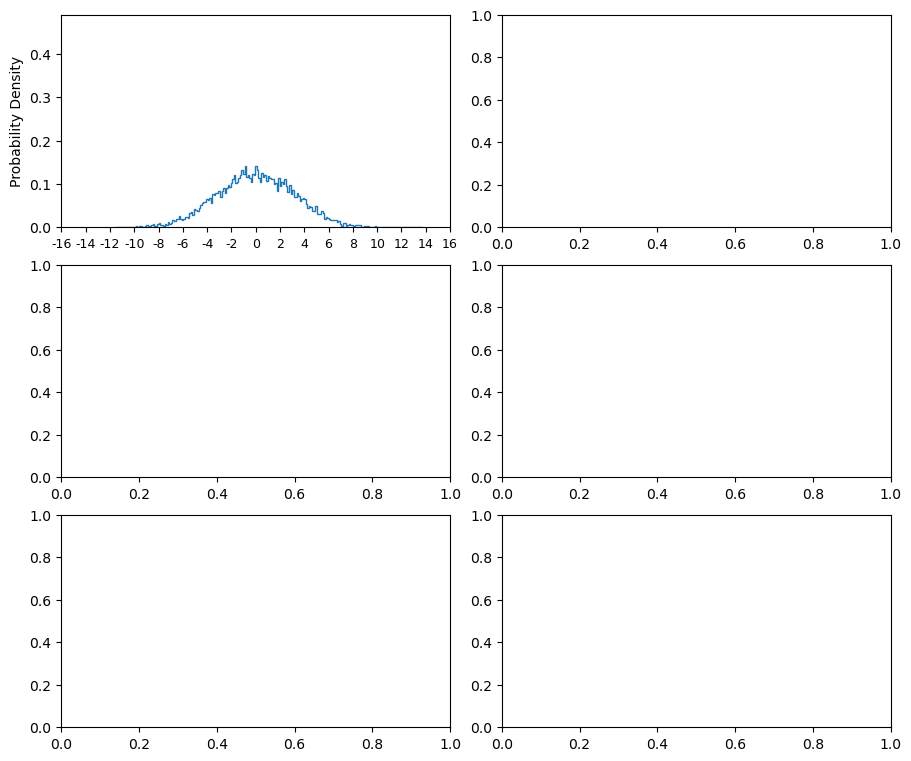

In [15]:

fig1, axes = plt.subplots(3,2, figsize=(9, 7.5), layout= 'constrained')
axes = axes.flatten()
bins = 400

index_list = [0,1,3,5,7]

axes[0].hist(x= moms_list[0], bins = 200, histtype='step', density=True)
axes[0].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
axes[0].set_xlim(basis[0],basis[-1])
axes[0].set_yticks(np.linspace(0,0.4,5))
axes[0].set_ylim(0,0.49)
axes[0].set_ylabel('Probability Density')
    

for i in range(1,6):
    axes[i].hist(x = moms_list[index_list[i]], weights= fracs_list[index_list[i-1]], bins = bins, histtype='step', density=True)
    axes[i].set_xticks(basis[0::2], basis[0::2], fontsize = 9)
    axes[i].set_xlim(basis[0],basis[-1])
    axes[i].set_yticks(np.linspace(0,0.4,5))
    axes[i].set_ylim(0,0.49)


axes[4].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[5].set_xlabel(r'$p$ ($\hbar k_{eff}$)')
axes[0].set_ylabel('Probability Density')
axes[2].set_ylabel('Probability Density')
axes[4].set_ylabel('Probability Density')

axes[0].text(10,0.4,r'0 Cycles')
axes[1].text(10,0.4,r'1 Cycles')
axes[2].text(10,0.4,r'2 Cycles')
axes[3].text(10,0.4,r'4 Cycles')
axes[4].text(10,0.4,r'6 Cycles')
axes[5].text(10,0.4,r'8 Cycles')

axes[0].text(-14,0.4,r'$T_{init}=15\mu K$')




# axes[0].text(r'0 Cycles')

plt.show()
